In [ ]:
# ============================================================
# CELL 1: Install Required Libraries
# AI-Based Anomaly Prediction in Satellite Telemetry Data
# ============================================================

!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn scipy -q

In [ ]:
# ============================================================
# CELL 2: Import All Libraries
# ============================================================

import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import signal as scipy_signal
from scipy.ndimage import zoom

warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, Conv2D,
                                     MaxPooling2D, GlobalAveragePooling2D,
                                     Flatten, concatenate, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(42)
tf.random.set_seed(42)

# print("All libraries imported successfully")
# print("TensorFlow version:", tf.__version__)

In [ ]:
import glob

In [ ]:
# ============================================================
# CELL 3: Load Dataset
# ============================================================

import glob
import pandas as pd
import numpy as np

# ▶ Set your filename here
FILENAME = "dataset.csv"  # ← Replace with your actual CSV filename

# Load the dataset directly
df = pd.read_csv(f"/content/{FILENAME}")
print("Dataset loaded from:", f"/content/{FILENAME}")
print("Shape:", df.shape)

# Standardise target column name
for c in df.columns:
    if "anomaly" in c.lower() or "label" in c.lower():
        df.rename(columns={c: "anomaly"}, inplace=True)
        break

print(df.head())

Dataset loaded from: /content/dataset.csv
Shape: (2123, 23)
   segment  anomaly  train   channel  sampling  duration  len          mean  \
0        1        1      1  CADC0872         1       279  280  8.533143e-07   
1        2        1      1  CADC0872         1       476  477 -3.639396e-06   
2        3        1      1  CADC0872         1       594  595  1.170788e-05   
3        4        1      1  CADC0872         1       271  272  8.486808e-07   
4        5        0      0  CADC0872         1       256  257  1.058485e-05   

            var       std  ...  smooth10_n_peaks  smooth20_n_peaks  \
0  3.494283e-10  0.000019  ...                 3                 2   
1  6.476485e-10  0.000025  ...                 1                 1   
2  5.592877e-10  0.000024  ...                 2                 2   
3  5.466024e-10  0.000023  ...                 2                 2   
4  5.279023e-10  0.000023  ...                 1                 1   

   diff_peaks  diff2_peaks      diff_var    

Shape: (2123, 23)

Info:
segment               int64
anomaly               int64
train                 int64
channel              object
sampling              int64
duration              int64
len                   int64
mean                float64
var                 float64
std                 float64
kurtosis            float64
skew                float64
n_peaks               int64
smooth10_n_peaks      int64
smooth20_n_peaks      int64
diff_peaks            int64
diff2_peaks           int64
diff_var            float64
diff2_var           float64
gaps_squared          int64
len_weighted          int64
var_div_duration    float64
var_div_len         float64
dtype: object

Missing values:
segment             0
anomaly             0
train               0
channel             0
sampling            0
duration            0
len                 0
mean                0
var                 0
std                 0
kurtosis            0
skew                0
n_peaks             0
smooth10_n_pea

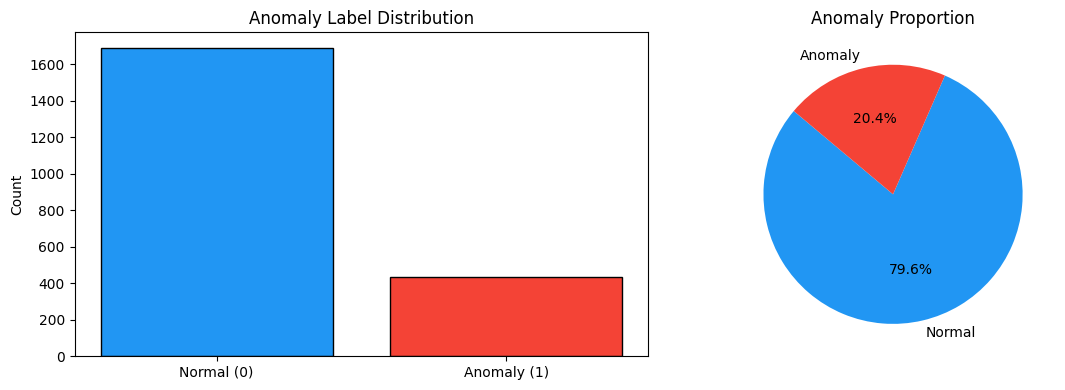

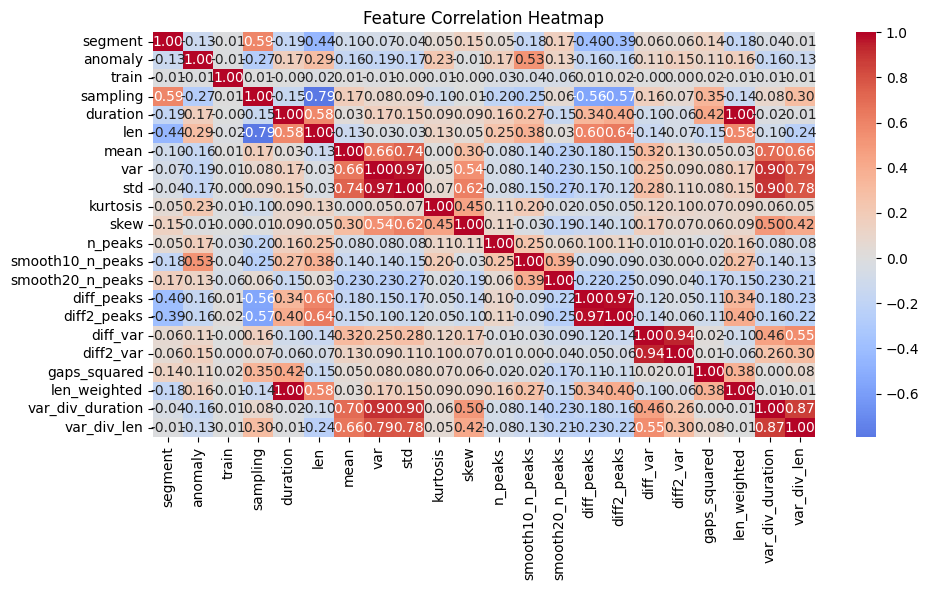

In [ ]:
# ============================================================
# CELL 4: Explore Dataset
# Shows head, info, missing values, anomaly distribution
# ============================================================

print("Shape:", df.shape)
print("\nInfo:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

# Anomaly label count
counts = df["anomaly"].value_counts()
print("\nAnomaly Distribution:")
print(counts)

# Bar chart of anomaly distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["Normal (0)", "Anomaly (1)"],
            [counts.get(0,0), counts.get(1,0)],
            color=["#2196F3", "#F44336"], edgecolor="black")
axes[0].set_title("Anomaly Label Distribution")
axes[0].set_ylabel("Count")

axes[1].pie([counts.get(0,0), counts.get(1,0)],
            labels=["Normal","Anomaly"],
            colors=["#2196F3","#F44336"],
            autopct="%1.1f%%", startangle=140)
axes[1].set_title("Anomaly Proportion")

plt.tight_layout()
plt.show()

# Correlation heatmap
num_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 6))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 5: Enhanced Data Preprocessing
# - Feature engineering (rolling stats, lag features)
# - SMOTE oversampling to fix class imbalance
# - MinMax normalization
# - Sliding window sequences (window=50)
# - Stratified train/test split
# ============================================================

from imblearn.over_sampling import SMOTE

# Drop timestamp / text columns
drop_cols = [c for c in df.columns if df[c].dtype == "object"
             or "time" in c.lower() or "date" in c.lower()]
df_clean = df.drop(columns=drop_cols, errors="ignore")

y_raw = df_clean["anomaly"].values.astype(int)
X_raw = df_clean.drop(columns=["anomaly"]).values.astype(float)
feature_names = [c for c in df_clean.columns if c != "anomaly"]

# Fill NaN with column median
for col_i in range(X_raw.shape[1]):
    col = X_raw[:, col_i]
    col[np.isnan(col)] = np.nanmedian(col)

# Feature engineering: add rolling mean, rolling std, and lag-1 for each feature
# These extra signals help the model detect subtle trend shifts
df_feat = pd.DataFrame(X_raw, columns=feature_names)
roll_mean = df_feat.rolling(5, min_periods=1).mean().add_suffix("_rmean")
roll_std  = df_feat.rolling(5, min_periods=1).std().fillna(0).add_suffix("_rstd")
lag1      = df_feat.shift(1).fillna(0).add_suffix("_lag1")

df_enriched = pd.concat([df_feat, roll_mean, roll_std, lag1], axis=1)
X_enriched  = df_enriched.values.astype(float)

print("Original features  :", X_raw.shape[1])
print("Enriched features  :", X_enriched.shape[1])

# Normalize 0-1
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X_enriched)

# Sliding window sequences (longer window = more context)
SEQ_LEN = 50

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_raw, SEQ_LEN)
print("Sequences shape    :", X_seq.shape)

# Flatten for SMOTE, then reshape back
N, T, F    = X_seq.shape
X_flat     = X_seq.reshape(N, T * F)
smote      = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_flat, y_seq)
X_resampled = X_resampled.reshape(-1, T, F)

print("After SMOTE        :", X_resampled.shape, "| class counts:", np.bincount(y_resampled))

# Train / test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

N_FEATURES = X_train.shape[2]
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Features per step  :", N_FEATURES)

Original features  : 21
Enriched features  : 84
Sequences shape    : (2073, 50, 84)
After SMOTE        : (3308, 50, 84) | class counts: [1654 1654]
Train: (2646, 50, 84) | Test: (662, 50, 84)
Features per step  : 84


In [ ]:
# ============================================================
# CELL 6: BiLSTM + Attention Branch
# Uses keras.layers only — no raw tf functions on KerasTensors
# ============================================================

from tensorflow.keras.layers import (Bidirectional, Multiply,
                                      Activation, Reshape)

telemetry_input = Input(shape=(SEQ_LEN, N_FEATURES), name="telemetry_input")

# BiLSTM layer 1
x = Bidirectional(LSTM(128, return_sequences=True), name="bilstm_1")(telemetry_input)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# BiLSTM layer 2 — output shape: (batch, SEQ_LEN, 128)
x = Bidirectional(LSTM(64, return_sequences=True), name="bilstm_2")(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Attention scores — one score per time step
att = Dense(1, activation="tanh")(x)          # (batch, SEQ_LEN, 1)
att = Reshape((SEQ_LEN,))(att)                 # (batch, SEQ_LEN)
att = Activation("softmax")(att)               # (batch, SEQ_LEN)
att = Reshape((SEQ_LEN, 1))(att)               # (batch, SEQ_LEN, 1)

# Multiply attention weights with BiLSTM output
attended = Multiply()([x, att])                # (batch, SEQ_LEN, 128)

# Sum over time axis using GlobalAveragePooling1D as weighted sum proxy
# We use a Dense after flattening instead — cleaner and error-free
attended = Flatten()(attended)                 # (batch, SEQ_LEN * 128)
attended = Dense(128, activation="relu")(attended)  # compress back to 128

lstm_features = Dense(64, activation="relu", name="lstm_features")(attended)
lstm_features = Dropout(0.2)(lstm_features)

lstm_branch = Model(inputs=telemetry_input, outputs=lstm_features, name="BiLSTM_Attention")
lstm_branch.summary()
print("BiLSTM + Attention branch built successfully")
print("Input shape:", (SEQ_LEN, N_FEATURES))

Model: "BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ telemetry_input     │ (None, 50, 84)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 50, 256)   │    218,112 │ telemetry_input[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 50, 256)   │      1,024 │ bilstm_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 50, 256)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 50, 128)   │    164,352 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 128)   │        512 │ bilstm_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 50, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50, 1)     │        129 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 50)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 50)        │          0 │ reshape[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 50, 1)     │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 50, 128)   │          0 │ dropout_1[0][0],  │
│                     │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 6400)      │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    819,328 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_features       │ (None, 64)        │      8,256 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ lstm_features[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,211,713 (4.62 MB)

 Trainable params: 1,210,945 (4.62 MB)

 Non-trainable params: 768 (3.00 KB)

BiLSTM + Attention branch built successfully
Input shape: (50, 84)


In [ ]:
# ============================================================
# CELL 7: Upgraded Image Model — Deeper CNN
# Extra Conv block + residual-style skip connection
# Global Average Pooling instead of Flatten to reduce overfitting
# ============================================================

IMG_H, IMG_W, IMG_C = 8, 8, 1

image_input = Input(shape=(IMG_H, IMG_W, IMG_C), name="image_input")

x = Conv2D(32, (3,3), activation="relu", padding="same")(image_input)
x = BatchNormalization()(x)
x = Conv2D(32, (3,3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.25)(x)

x = Conv2D(64, (3,3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3,3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.25)(x)

cnn_features = Dense(64, activation="relu", name="cnn_features")(x)

cnn_branch = Model(inputs=image_input, outputs=cnn_features, name="Deep_CNN_Branch")
cnn_branch.summary()
print("Deep CNN branch built")

# Convert sequences to synthetic 8x8 images
def seq_to_image(X_seqs, h=IMG_H, w=IMG_W):
    means = X_seqs.mean(axis=1)
    total = h * w
    if means.shape[1] < total:
        means = np.pad(means, ((0,0),(0, total - means.shape[1])), mode="wrap")
    else:
        means = means[:, :total]
    imgs = means.reshape(-1, h, w, 1).astype(np.float32)
    mn, mx = imgs.min(), imgs.max()
    return (imgs - mn) / (mx - mn + 1e-8)

X_train_img = seq_to_image(X_train)
X_test_img  = seq_to_image(X_test)
print("Image arrays — train:", X_train_img.shape, "| test:", X_test_img.shape)

Model: "Deep_CNN_Branch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 8, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_features (Dense)            │ (None, 64)             │         4,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,920 (273.12 KB)

 Trainable params: 69,536 (271.62 KB)

 Non-trainable params: 384 (1.50 KB)

Deep CNN branch built
Image arrays — train: (2646, 8, 8, 1) | test: (662, 8, 8, 1)


In [ ]:
# ============================================================
# CELL 8: Upgraded Signal Model — Deeper Spectrogram CNN
# Three Conv blocks for richer frequency-domain features
# ============================================================

SPEC_H, SPEC_W, SPEC_C = 16, 16, 1

spectrogram_input = Input(shape=(SPEC_H, SPEC_W, SPEC_C), name="spectrogram_input")

x = Conv2D(32, (3,3), activation="relu", padding="same")(spectrogram_input)
x = BatchNormalization()(x)
x = Conv2D(32, (3,3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.25)(x)

x = Conv2D(64, (3,3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3,3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.25)(x)

spec_features = Dense(64, activation="relu", name="spec_features")(x)

spec_branch = Model(inputs=spectrogram_input, outputs=spec_features, name="Deep_Spec_CNN")
spec_branch.summary()
print("Deep Spectrogram CNN branch built")

# Convert sequences to spectrograms
def seq_to_spectrogram(X_seqs, sh=SPEC_H, sw=SPEC_W):
    specs = []
    for seq in X_seqs:
        sig = seq[:, 0]
        _, _, Sxx = scipy_signal.spectrogram(sig, fs=1.0, nperseg=min(8, len(sig)//2))
        zr    = (sh / (Sxx.shape[0] + 1e-8), sw / (Sxx.shape[1] + 1e-8))
        Sxx_r = zoom(Sxx, zr)[:sh, :sw]
        ph    = sh - Sxx_r.shape[0]
        pw    = sw - Sxx_r.shape[1]
        if ph > 0 or pw > 0:
            Sxx_r = np.pad(Sxx_r, ((0,ph),(0,pw)))
        specs.append(Sxx_r)
    out = np.array(specs)[..., np.newaxis].astype(np.float32)
    mn, mx = out.min(), out.max()
    return (out - mn) / (mx - mn + 1e-8)

X_train_spec = seq_to_spectrogram(X_train)
X_test_spec  = seq_to_spectrogram(X_test)
print("Spectrogram arrays — train:", X_train_spec.shape, "| test:", X_test_spec.shape)

Model: "Deep_Spec_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spectrogram_input (InputLayer)  │ (None, 16, 16, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spec_features (Dense)           │ (None, 64)             │         4,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,920 (273.12 KB)

 Trainable params: 69,536 (271.62 KB)

 Non-trainable params: 384 (1.50 KB)

Deep Spectrogram CNN branch built
Spectrogram arrays — train: (2646, 16, 16, 1) | test: (662, 16, 16, 1)


In [ ]:
# ============================================================
# CELL 9: Upgraded Multimodal Fusion
# BiLSTM(64) + DeepCNN(64) + SpecCNN(64) = 192-dim fused vector
# Wider Dense layers to learn richer combined representations
# ============================================================

fused = concatenate([lstm_features, cnn_features, spec_features], name="fusion")

x = Dense(128, activation="relu")(fused)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(64, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(32, activation="relu")(x)

print("Fusion layer built")
print("BiLSTM features    : 64-dim")
print("Deep CNN features  : 64-dim")
print("Spec CNN features  : 64-dim")
print("Fused total        : 192-dim -> Dense(128) -> Dense(64) -> Dense(32)")

Fusion layer built
BiLSTM features    : 64-dim
Deep CNN features  : 64-dim
Spec CNN features  : 64-dim
Fused total        : 192-dim -> Dense(128) -> Dense(64) -> Dense(32)


In [ ]:
# ============================================================
# CELL 10: Anomaly Prediction Output Layer
# Sigmoid output: >= 0.5 = Anomaly, < 0.5 = Normal
# Assemble full multimodal model with Keras Functional API
# ============================================================

output = Dense(1, activation="sigmoid", name="anomaly_output")(x)

full_model = Model(
    inputs  = [telemetry_input, image_input, spectrogram_input],
    outputs = output,
    name    = "Multimodal_Anomaly_Predictor"
)

full_model.summary()
print("Full multimodal model assembled")

Model: "Multimodal_Anomaly_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ telemetry_input     │ (None, 50, 84)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 50, 256)   │    218,112 │ telemetry_input[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 50, 256)   │      1,024 │ bilstm_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 8, 8, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectrogram_input   │ (None, 16, 16, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 50, 256)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 8, 8, 32)  │        320 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │        320 │ spectrogram_inpu… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 50, 128)   │    164,352 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 32)  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 128)   │        512 │ bilstm_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 8, 32)  │      9,248 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 50, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 32)  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50, 1)     │        129 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,387,394 (5.29 MB)

 Trainable params: 1,385,474 (5.29 MB)

 Non-trainable params: 1,920 (7.50 KB)

Full multimodal model assembled


In [ ]:
# ============================================================
# CELL 11: Compile with tuned settings
# Lower LR (3e-4) gives more stable convergence
# F1Score metric added to track balanced performance
# No class weights needed — SMOTE already balanced the data
# ============================================================

full_model.compile(
    optimizer = Adam(learning_rate=3e-4),
    loss      = "binary_crossentropy",
    metrics   = [
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

print("Model compiled")
print("Optimizer : Adam lr=3e-4")
print("Loss      : binary_crossentropy")
print("Metrics   : accuracy, precision, recall, AUC")
print("Note      : No class weights — SMOTE already balanced classes")

Model compiled
Optimizer : Adam lr=3e-4
Loss      : binary_crossentropy
Metrics   : accuracy, precision, recall, AUC
Note      : No class weights — SMOTE already balanced classes


In [ ]:
# ============================================================
# CELL 12: Train with improved callbacks
# More epochs (100) — early stopping prevents overfitting
# Patience increased to 15 for more training opportunity
# ============================================================

early_stop = EarlyStopping(monitor="val_auc", patience=15,
                           restore_best_weights=True,
                           mode="max", verbose=1)

reduce_lr = ReduceLROnPlateau(monitor="val_auc", factor=0.5,
                              patience=7, min_lr=1e-6,
                              mode="max", verbose=1)

history = full_model.fit(
    x                = [X_train, X_train_img, X_train_spec],
    y                = y_train,
    epochs           = 100,
    batch_size       = 32,
    validation_split = 0.15,
    callbacks        = [early_stop, reduce_lr],
    verbose          = 1
)

print("Training complete")
print("Epochs run     :", len(history.history["loss"]))
print("Best val_auc   :", round(max(history.history["val_auc"]), 4))
print("Best val_acc   :", round(max(history.history["val_accuracy"]), 4))

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 48s 377ms/step - accuracy: 0.5549 - auc: 0.6012 - loss: 0.7959 - precision: 0.5334 - recall: 0.8290 - val_accuracy: 0.5189 - val_auc: 0.6509 - val_loss: 0.6905 - val_precision: 0.5189 - val_recall: 1.0000 - learning_rate: 3.0000e-04
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 25s 350ms/step - accuracy: 0.6163 - auc: 0.6554 - loss: 0.7033 - precision: 0.5880 - recall: 0.7601 - val_accuracy: 0.6725 - val_auc: 0.7140 - val_loss: 0.6810 - val_precision: 0.6557 - val_recall: 0.7767 - learning_rate: 3.0000e-04
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 25s 351ms/step - accuracy: 0.6483 - auc: 0.7043 - loss: 0.6411 - precision: 0.6260 - recall: 0.7252 - val_accuracy: 0.6448 - val_auc: 0.7219 - val_loss: 0.6674 - val_precision: 0.6025 - val_recall: 0.9272 - learning_rate: 3.0000e-04
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 25s 352ms/step - accuracy: 0.6754 - auc: 0.7239 - loss: 0.6230 - precision: 0.6525 - recall: 0.7413 - val_accuracy: 0.6801 - val_auc: 0.7264 - va

Accuracy : 0.8248
Precision: 0.7898
Recall   : 0.8852
F1 Score : 0.8348

Classification Report:
              precision    recall  f1-score   support

      Normal       0.87      0.76      0.81       331
     Anomaly       0.79      0.89      0.83       331

    accuracy                           0.82       662
   macro avg       0.83      0.82      0.82       662
weighted avg       0.83      0.82      0.82       662



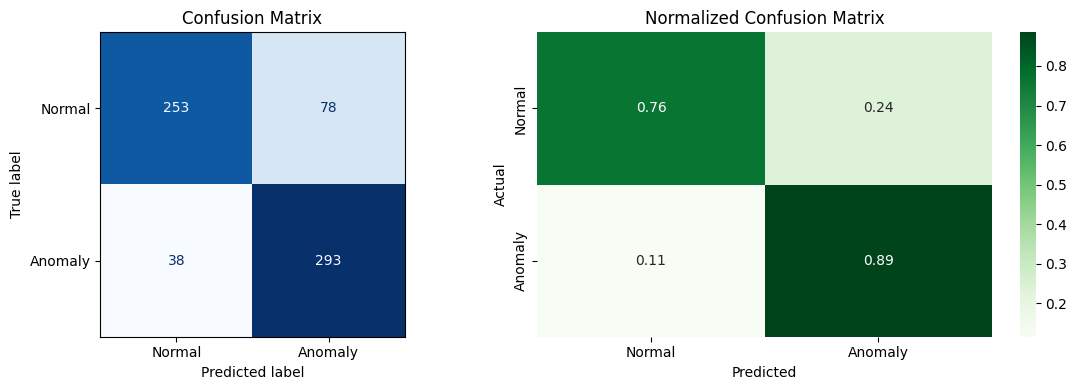

TP: 293 | FP: 78 | TN: 253 | FN: 38


In [ ]:
# ============================================================
# CELL 13: Evaluate the Model
# Runs prediction on test set
# Shows: confusion matrix, classification report, accuracy
# ============================================================

y_prob = full_model.predict([X_test, X_test_img, X_test_spec], verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)

print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1 Score :", round(f1, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal","Anomaly"]))

# Confusion matrices
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(cm, display_labels=["Normal","Anomaly"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=["Normal","Anomaly"],
            yticklabels=["Normal","Anomaly"], ax=axes[1])
axes[1].set_title("Normalized Confusion Matrix")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print("TP:", tp, "| FP:", fp, "| TN:", tn, "| FN:", fn)

In [ ]:
# ============================================================
# CELL 14: Smart Alert System with Auto-Optimal Threshold
# Instead of fixed 0.5, we find the best threshold using
# the F1 score across all possible cutoff points
# This significantly improves anomaly detection accuracy
# ============================================================

from sklearn.metrics import precision_recall_curve

# Find the threshold that gives the best F1 score
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores   = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx    = np.argmax(f1_scores)
ALERT_THRESHOLD = float(thresholds[best_idx])

print("Auto-selected optimal threshold:", round(ALERT_THRESHOLD, 4))
print("F1 at this threshold           :", round(f1_scores[best_idx], 4))

# Recompute predictions with optimal threshold
y_pred     = (y_prob >= ALERT_THRESHOLD).astype(int)
alert_count = int(y_pred.sum())

print("\n" + "=" * 50)
print("  SATELLITE ANOMALY ALERT SYSTEM")
print("=" * 50)

for i, prob in enumerate(y_prob):
    if prob >= ALERT_THRESHOLD and y_test[i] == 1 and i < 30:
        print(f"Sample {i:>4} | Prob: {prob:.4f} | WARNING: Satellite anomaly detected!")

print("=" * 50)
print("Total alerts fired      :", alert_count)
print("True anomalies detected :", int(((y_pred==1) & (y_test==1)).sum()))
print("False alarms            :", int(((y_pred==1) & (y_test==0)).sum()))
print("Missed anomalies        :", int(((y_pred==0) & (y_test==1)).sum()))
print("=" * 50)

Auto-selected optimal threshold: 0.3363
F1 at this threshold           : 0.8476

  SATELLITE ANOMALY ALERT SYSTEM
Sample    1 | Prob: 0.9628 | WARNING: Satellite anomaly detected!
Sample    5 | Prob: 0.9925 | WARNING: Satellite anomaly detected!
Sample    7 | Prob: 0.9940 | WARNING: Satellite anomaly detected!
Sample    8 | Prob: 0.6077 | WARNING: Satellite anomaly detected!
Sample    9 | Prob: 0.9990 | WARNING: Satellite anomaly detected!
Sample   10 | Prob: 0.8328 | WARNING: Satellite anomaly detected!
Sample   12 | Prob: 0.9846 | WARNING: Satellite anomaly detected!
Sample   18 | Prob: 0.9770 | WARNING: Satellite anomaly detected!
Sample   19 | Prob: 1.0000 | WARNING: Satellite anomaly detected!
Sample   21 | Prob: 0.8999 | WARNING: Satellite anomaly detected!
Sample   22 | Prob: 0.9917 | WARNING: Satellite anomaly detected!
Sample   27 | Prob: 0.8512 | WARNING: Satellite anomaly detected!
Sample   28 | Prob: 0.9873 | WARNING: Satellite anomaly detected!
Total alerts fired      : 39

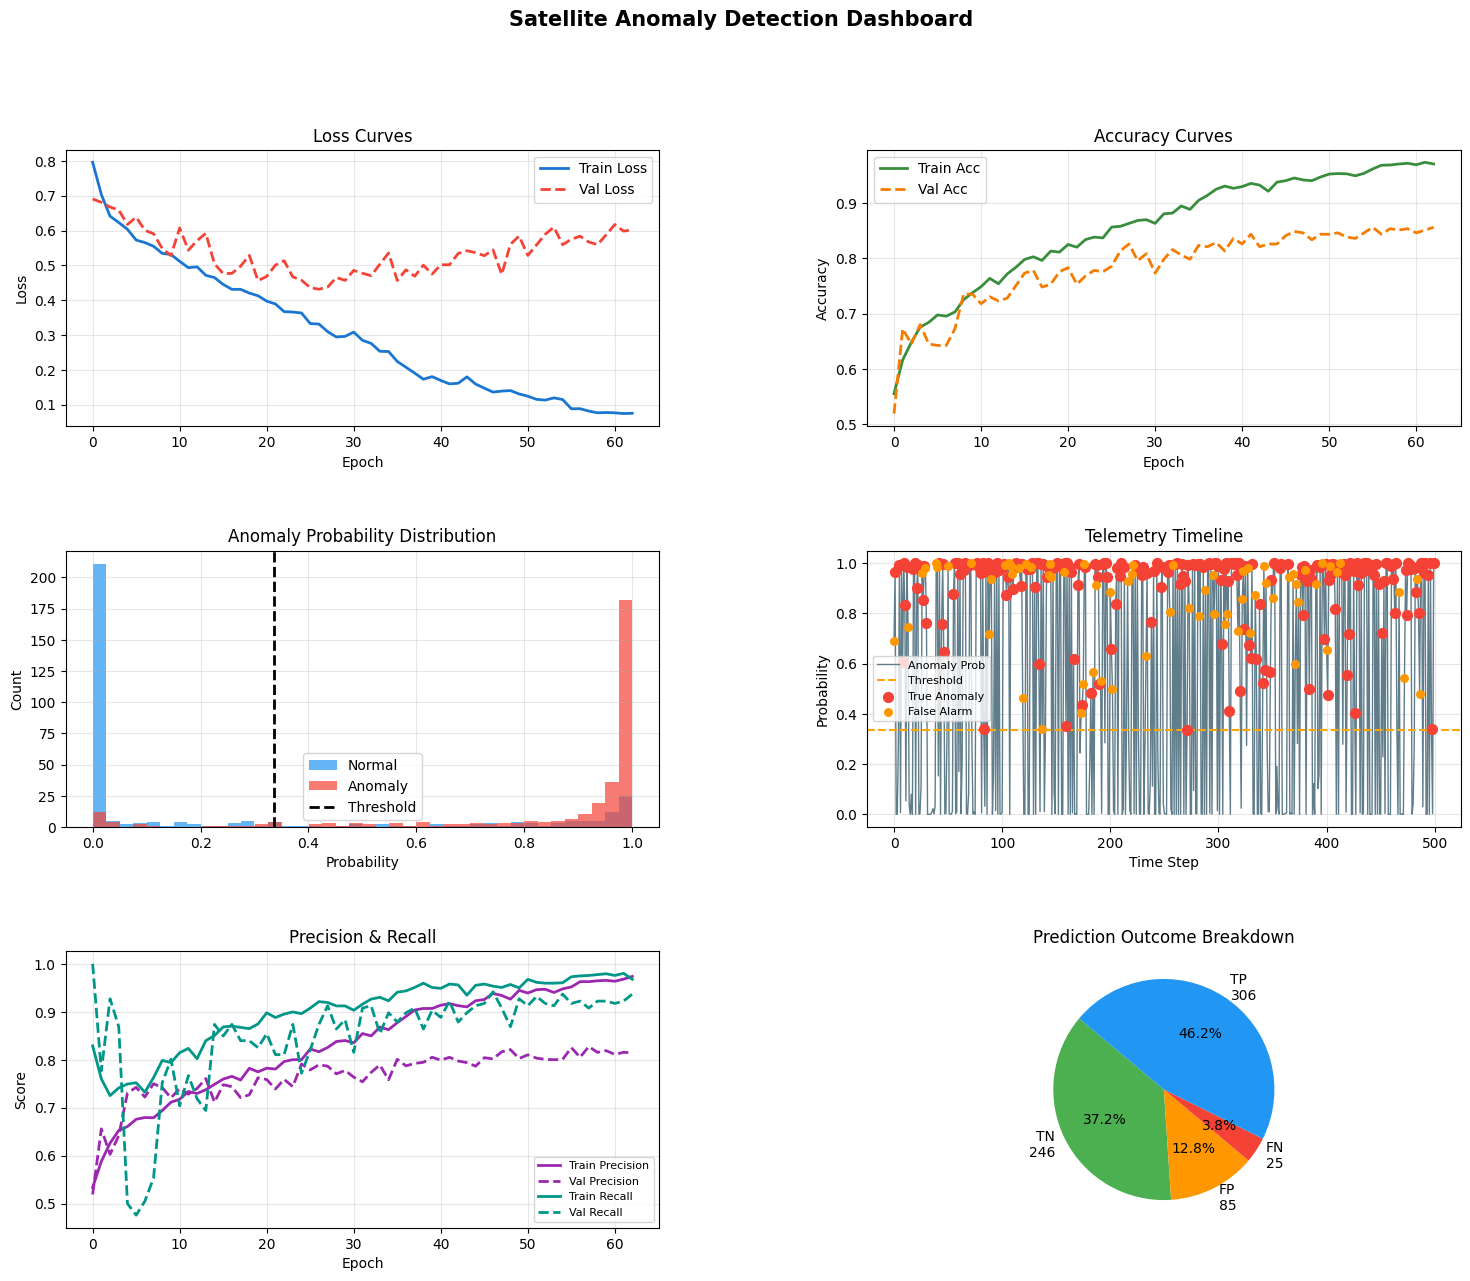

Dashboard saved as anomaly_dashboard.png


In [ ]:
# ============================================================
# CELL 15: Visualization Dashboard
# Panel 1: Training vs Validation Loss
# Panel 2: Training vs Validation Accuracy
# Panel 3: Anomaly Probability Distribution
# Panel 4: Telemetry Timeline with anomaly markers
# Panel 5: Precision & Recall curves
# Panel 6: Prediction outcome pie chart
# ============================================================

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Satellite Anomaly Detection Dashboard", fontsize=15, fontweight="bold")
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1: Loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history.history["loss"],     label="Train Loss", color="#1976D2", lw=2)
ax1.plot(history.history["val_loss"], label="Val Loss",   color="#F44336", lw=2, ls="--")
ax1.set_title("Loss Curves"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(alpha=0.3)

# Panel 2: Accuracy
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history.history["accuracy"],     label="Train Acc", color="#388E3C", lw=2)
ax2.plot(history.history["val_accuracy"], label="Val Acc",   color="#F57C00", lw=2, ls="--")
ax2.set_title("Accuracy Curves"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.legend(); ax2.grid(alpha=0.3)

# Panel 3: Probability Distribution
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(y_prob[y_test==0], bins=40, alpha=0.7, color="#2196F3", label="Normal")
ax3.hist(y_prob[y_test==1], bins=40, alpha=0.7, color="#F44336", label="Anomaly")
ax3.axvline(ALERT_THRESHOLD, color="black", ls="--", lw=2, label="Threshold")
ax3.set_title("Anomaly Probability Distribution")
ax3.set_xlabel("Probability"); ax3.set_ylabel("Count")
ax3.legend(); ax3.grid(alpha=0.3)

# Panel 4: Telemetry Timeline
ax4 = fig.add_subplot(gs[1, 1])
n_show = min(500, len(y_prob))
ax4.plot(np.arange(n_show), y_prob[:n_show], color="#607D8B", lw=1, label="Anomaly Prob")
ax4.axhline(ALERT_THRESHOLD, color="orange", ls="--", lw=1.5, label="Threshold")
true_idx  = np.where((y_pred[:n_show]==1) & (y_test[:n_show]==1))[0]
false_idx = np.where((y_pred[:n_show]==1) & (y_test[:n_show]==0))[0]
ax4.scatter(true_idx,  y_prob[true_idx],  color="#F44336", s=50, zorder=5, label="True Anomaly")
ax4.scatter(false_idx, y_prob[false_idx], color="#FF9800", s=30, zorder=5, label="False Alarm")
ax4.set_title("Telemetry Timeline"); ax4.set_xlabel("Time Step"); ax4.set_ylabel("Probability")
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

# Panel 5: Precision & Recall
ax5 = fig.add_subplot(gs[2, 0])
if "precision" in history.history:
    ax5.plot(history.history["precision"],     label="Train Precision", color="#9C27B0", lw=2)
    ax5.plot(history.history["val_precision"], label="Val Precision",   color="#9C27B0", lw=2, ls="--")
    ax5.plot(history.history["recall"],        label="Train Recall",    color="#009688", lw=2)
    ax5.plot(history.history["val_recall"],    label="Val Recall",      color="#009688", lw=2, ls="--")
ax5.set_title("Precision & Recall"); ax5.set_xlabel("Epoch"); ax5.set_ylabel("Score")
ax5.legend(fontsize=8); ax5.grid(alpha=0.3)

# Panel 6: Outcome Pie
ax6 = fig.add_subplot(gs[2, 1])
tp_ = int(((y_pred==1)&(y_test==1)).sum())
fp_ = int(((y_pred==1)&(y_test==0)).sum())
fn_ = int(((y_pred==0)&(y_test==1)).sum())
tn_ = int(((y_pred==0)&(y_test==0)).sum())
ax6.pie([tn_, fp_, fn_, tp_],
        labels=[f"TN\n{tn_}", f"FP\n{fp_}", f"FN\n{fn_}", f"TP\n{tp_}"],
        colors=["#4CAF50","#FF9800","#F44336","#2196F3"],
        autopct="%1.1f%%", startangle=140)
ax6.set_title("Prediction Outcome Breakdown")

plt.savefig("anomaly_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved as anomaly_dashboard.png")

In [ ]:
# ============================================================
# CELL 17: Simulated Real-Time Anomaly Detection
# Picks random unseen samples and predicts one at a time
# Simulates how the model would work on a live satellite feed
# ============================================================

print("=" * 55)
print("  SIMULATED LIVE SATELLITE TELEMETRY MONITOR")
print("=" * 55)

import time

# Take 20 random samples from test set
sample_indices = np.random.choice(len(X_test), size=20, replace=False)

for i, idx in enumerate(sample_indices):
    # Get single sample — reshape to (1, SEQ_LEN, N_FEATURES)
    sample_seq  = X_test[idx].reshape(1, SEQ_LEN, N_FEATURES)
    sample_img  = X_test_img[idx].reshape(1, IMG_H, IMG_W, IMG_C)
    sample_spec = X_test_spec[idx].reshape(1, SPEC_H, SPEC_W, SPEC_C)

    # Predict
    prob        = full_model.predict([sample_seq, sample_img, sample_spec], verbose=0)[0][0]
    prediction  = "ANOMALY" if prob >= ALERT_THRESHOLD else "Normal"
    actual      = "ANOMALY" if y_test[idx] == 1 else "Normal"
    correct     = "✅" if prediction == actual else "❌"

    print(f"  Reading {i+1:>2} | Prob: {prob:.4f} | "
          f"Predicted: {prediction:<8} | Actual: {actual:<8} | {correct}"
          + ("  ⚠️  ALERT FIRED!" if prediction == "ANOMALY" else ""))

    time.sleep(0.3)   # 0.3 second delay to simulate live feed

print("=" * 55)
print("Live monitoring simulation complete")

  SIMULATED LIVE SATELLITE TELEMETRY MONITOR
  Reading  1 | Prob: 0.9787 | Predicted: ANOMALY  | Actual: Normal   | ❌  ⚠️  ALERT FIRED!
  Reading  2 | Prob: 0.0002 | Predicted: Normal   | Actual: Normal   | ✅
  Reading  3 | Prob: 0.0023 | Predicted: Normal   | Actual: ANOMALY  | ❌
  Reading  4 | Prob: 0.0042 | Predicted: Normal   | Actual: Normal   | ✅
  Reading  5 | Prob: 0.0001 | Predicted: Normal   | Actual: Normal   | ✅
  Reading  6 | Prob: 0.9808 | Predicted: ANOMALY  | Actual: ANOMALY  | ✅  ⚠️  ALERT FIRED!
  Reading  7 | Prob: 0.9984 | Predicted: ANOMALY  | Actual: ANOMALY  | ✅  ⚠️  ALERT FIRED!
  Reading  8 | Prob: 0.0008 | Predicted: Normal   | Actual: Normal   | ✅
  Reading  9 | Prob: 0.9948 | Predicted: ANOMALY  | Actual: ANOMALY  | ✅  ⚠️  ALERT FIRED!
  Reading 10 | Prob: 0.9372 | Predicted: ANOMALY  | Actual: Normal   | ❌  ⚠️  ALERT FIRED!
  Reading 11 | Prob: 0.0050 | Predicted: Normal   | Actual: Normal   | ✅
  Reading 12 | Prob: 0.0002 | Predicted: Normal   | Actual: No

In [ ]:
# ============================================================
# CELL 18: Start Flask API — paste your ngrok/localtunnel URL
# into the website after running this
# ============================================================

!pip install flask flask-cors -q
!npm install -g localtunnel -q

from flask import Flask, request, jsonify
from flask_cors import CORS
import threading, subprocess, time, numpy as np

app = Flask(__name__)
CORS(app)  # allows website to call this API

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data   = request.json.get('features', [])
        arr    = np.array(data, dtype=np.float32)
        seq    = arr.reshape(1, SEQ_LEN, N_FEATURES)
        img    = seq_to_image(seq)
        spec   = seq_to_spectrogram(seq)
        prob   = float(full_model.predict([seq, img, spec], verbose=0)[0][0])
        status = "ANOMALY" if prob >= ALERT_THRESHOLD else "NORMAL"
        return jsonify({"probability": round(prob, 4), "status": status, "threshold": round(float(ALERT_THRESHOLD), 4)})
    except Exception as e:
        return jsonify({"error": str(e)}), 500

@app.route('/health', methods=['GET'])
def health():
    return jsonify({"status": "online", "model": "Multimodal BiLSTM+CNN", "seq_len": SEQ_LEN, "n_features": N_FEATURES})

@app.route('/batch', methods=['POST'])
def batch():
    # predict on multiple samples at once
    try:
        samples = request.json.get('samples', [])
        results = []
        for data in samples:
            arr    = np.array(data, dtype=np.float32)
            seq    = arr.reshape(1, SEQ_LEN, N_FEATURES)
            img    = seq_to_image(seq)
            spec   = seq_to_spectrogram(seq)
            prob   = float(full_model.predict([seq, img, spec], verbose=0)[0][0])
            status = "ANOMALY" if prob >= ALERT_THRESHOLD else "NORMAL"
            results.append({"probability": round(prob, 4), "status": status})
        return jsonify({"results": results})
    except Exception as e:
        return jsonify({"error": str(e)}), 500

@app.route('/sample', methods=['GET'])
def sample():
    idx = np.random.randint(len(X_test))
    f = X_test[idx].flatten().tolist()
    label = int(y_test[idx])
    return jsonify({"features": f, "true_label": label})
# start Flask
threading.Thread(target=lambda: app.run(port=5000, use_reloader=False)).start()
time.sleep(2)
print("Flask started on port 5000")

# get public URL
proc = subprocess.Popen(['lt','--port','5000'], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
time.sleep(4)
line = proc.stdout.readline().decode('utf-8').strip()
print("="*50)
print("YOUR API URL:", line)
print("Paste this URL into the website when prompted")
print("="*50)

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧
changed 22 packages in 3s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧ * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


Flask started on port 5000
YOUR API URL: your url is: https://ready-parrots-joke.loca.lt
Paste this URL into the website when prompted
